# Bee Orientation Estimation

Trains and evaluates CNNs that predict the orientation $\theta$ of a bee
centered in an image patch (produced by `preprocessing.py`).

**Key idea:** instead of regressing $\theta$ directly (which is discontinuous
at the $\pm\pi$ wrap-around), the model outputs two continuous values
$(\sin\theta, \cos\theta)$. The orientation is reconstructed via
$\hat\theta = \operatorname{atan2}(\widehat{\sin\theta}, \widehat{\cos\theta})$.

- **Loss:** cosine loss $1 - \cos(\Delta\theta)$ — the raw output is
  L2-normalized onto the unit circle and compared to the unit target,
  which equals the MSE of the normalized $(\sin, \cos)$ pair (up to a
  factor of 2) and depends *only* on the angular error:
  $\approx \Delta\theta^2/2$ for small errors, flattening
  (outlier-robust) towards $180°$.
- **Error metric:** signed angular error
  $\Delta\theta = \operatorname{atan2}(\sin(\theta - \hat\theta), \cos(\theta - \hat\theta))$,
  reported as mean/median absolute error in degrees, plus threshold accuracies
  and an axial (mod-180°) companion metric.
- **Models:** ResNet-18, ResNet-50, MobileNetV4 (all via `timm`).

**Head/tail ambiguity:** if the tracker's `orientation_angle` comes from an
axial estimator (e.g. an ellipse fit), labels do not distinguish head from
tail and are arbitrarily flipped by 180°. Training $(\sin\theta, \cos\theta)$
against such labels is unlearnable noise (MAE saturates near 90°). In that
case set `Config.axial_labels = True`: the model then regresses
$(\sin 2\theta, \cos 2\theta)$ and decodes with $\operatorname{atan2}(\cdot)/2$.

In [1]:
# Uncomment on first run if dependencies are missing on the HPC node
# (ipywidgets is what renders the animated tqdm progress bars in Jupyter):
# %pip install --user timm torch torchvision pandas matplotlib tqdm ipywidgets

In [4]:
from __future__ import annotations

import json
import math
import os
import random
from dataclasses import dataclass, replace
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

# Sample and BeeOrientationDataset live in bee_dataset.py (not in a notebook
# cell) so that DataLoader worker processes can import them — forkserver
# workers re-import the defining module, and `__main__` classes don't survive
# that. Restart the kernel after editing bee_dataset.py.
from bee_dataset import BeeOrientationDataset, Sample

## Configuration

Everything tunable lives in a single `Config` dataclass.

In [5]:
@dataclass
class Config:
    # --- data ---
    data_dir: Path = Path("/scratch/cvcdt011/data")
    crops_subdir: str = "crops"
    trajectories_subdir: str = "rec1_trajectories"
    video_name: str = "rec1.mp4"
    # Label convention, confirmed visually via the gate cell: orientation_angle
    # is a compass bearing in degrees (0 = up, 90 = right, clockwise on screen).
    angles_in_degrees: bool = True
    # True if orientation_angle is axial (head/tail ambiguous, e.g. from an ellipse
    # fit): the model then regresses [sin(2*theta), cos(2*theta)] and all primary
    # error metrics are computed mod 180 degrees.
    axial_labels: bool = False
    # Maps orientation_angle into display coordinates (x right, y down), where all
    # downstream code assumes theta = atan2(dy, dx). See ANGLE_REMAPS:
    #   "compass"     0=up, 90=right, clockwise   -> theta - pi/2   (our data)
    #   "ydown"       already display convention (identity)
    #   "yup"         y-up / math convention      -> -theta
    #   "transposed"  axes swapped                -> pi/2 - theta
    angle_convention: str = "compass"
    expected_crop_size: int = 100     # 2 * half_size from preprocessing.py
    filter_partial_crops: bool = True # drop border crops smaller than expected_crop_size
    # Source frame (width, height) for the border-crop check; read from the video
    # if None. Set manually if the video is not accessible from this node.
    frame_size: tuple[int, int] | None = None
    index_cache_path: Path = Path("sample_index.csv")
    use_index_cache: bool = True      # delete the cache file after changing data settings

    # --- split ---
    split_strategy: str = "trajectory"  # "trajectory" (no temporal leakage) or "random"
    val_fraction: float = 0.15
    test_fraction: float = 0.15
    seed: int = 42

    # --- input pipeline ---
    image_size: int = 224
    batch_size: int = 64
    num_workers: int = 4
    # Rotation augmentation rotates the patch and adjusts theta accordingly.
    # It assumes theta is measured as atan2(dy, dx) in image coordinates (y pointing
    # down). Verify the label convention before enabling, otherwise labels get corrupted.
    rotation_augment: bool = False

    # --- models / training ---
    model_names: tuple[str, ...] = ("resnet18", "resnet50", "mobilenetv4_conv_medium")
    pretrained: bool = True
    epochs: int = 15
    lr: float = 3e-4
    weight_decay: float = 1e-4
    use_amp: bool = True
    # Model weights (~50-100 MB each) belong on scratch, not in the quota-limited
    # home directory / repo.
    checkpoint_dir: Path = Path("/scratch/cvcdt004/checkpoints")

    @property
    def crops_dir(self) -> Path:
        return self.data_dir / self.crops_subdir

    @property
    def trajectories_dir(self) -> Path:
        return self.data_dir / self.trajectories_subdir

    @property
    def video_path(self) -> Path:
        return self.data_dir / self.video_name

    @property
    def angle_multiplier(self) -> float:
        """2.0 for axial labels (period 180°), 1.0 for directional labels."""
        return 2.0 if self.axial_labels else 1.0


cfg = Config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(cfg.seed)

Device: cuda


## Sample index

Each trajectory file `rec1_trajectories/<traj_id>.txt` holds rows
`frame_nb, position_x, position_y, object_class, orientation_angle`.
A sample pairs the crop `crops/<traj_id>/frame_<frame>.png` with its
orientation label.

Border crops are filtered **geometrically**: `preprocessing.py` clips a crop
exactly when the bee position is within `half_size` of the frame border, so
partial crops can be identified from the trajectory positions alone — no
image needs to be opened (per-file I/O is what makes indexing slow on a
scratch filesystem). A spot check on a few random crops verifies the rule;
existence is checked with one directory listing per trajectory.

In [6]:
# Remaps a raw label angle into display convention (see Config.angle_convention).
# "compass" is our data: bearing 0=up, 90=right (clockwise), i.e. the on-screen
# direction is (sin t, -cos t), which equals display angle t - pi/2.
ANGLE_REMAPS: dict[str, Callable[[float], float]] = {
    "compass": lambda t: t - math.pi / 2,
    "ydown": lambda t: t,
    "yup": lambda t: -t,
    "transposed": lambda t: math.pi / 2 - t,
}


def get_frame_size(cfg: Config) -> tuple[int, int]:
    """Source frame (width, height), from Config or read once from the video."""
    if cfg.frame_size is not None:
        return cfg.frame_size
    import cv2

    cap = cv2.VideoCapture(str(cfg.video_path))
    try:
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    finally:
        cap.release()
    if w <= 0 or h <= 0:
        raise RuntimeError(
            f"Could not read frame size from {cfg.video_path} — set Config.frame_size manually."
        )
    return w, h


def load_samples(cfg: Config) -> tuple[list[Sample], int]:
    """Build the (crop path, orientation) index from the trajectory files.

    Returns (samples, n_partial_dropped). Avoids per-file I/O: crop existence
    is checked against one directory listing per trajectory, and border crops
    are detected from the bee position (same clipping rule as preprocessing.py).
    """
    half = cfg.expected_crop_size // 2
    frame_w, frame_h = get_frame_size(cfg) if cfg.filter_partial_crops else (0, 0)
    remap = ANGLE_REMAPS[cfg.angle_convention]

    samples: list[Sample] = []
    n_partial = 0
    for traj_file in sorted(cfg.trajectories_dir.glob("*.txt")):
        traj_id = traj_file.stem
        crop_dir = cfg.crops_dir / traj_id
        if not crop_dir.exists():
            continue
        existing = {entry.name for entry in os.scandir(crop_dir)}
        for line in traj_file.read_text().splitlines():
            parts = line.strip().split(",")
            if len(parts) < 5:
                continue
            frame = int(parts[0])
            filename = f"frame_{frame:06d}.png"
            if filename not in existing:
                continue
            if cfg.filter_partial_crops:
                # preprocessing.py indexes crop *rows* with position_x and
                # *columns* with position_y, so x is clipped against the frame
                # height and y against the width.
                x = int(round(float(parts[1])))
                y = int(round(float(parts[2])))
                if x - half < 0 or x + half > frame_h or y - half < 0 or y + half > frame_w:
                    n_partial += 1
                    continue
            theta = float(parts[4])
            if cfg.angles_in_degrees:
                theta = math.radians(theta)
            theta = remap(theta)
            samples.append(Sample(path=crop_dir / filename, theta=theta, traj_id=traj_id))
    return samples, n_partial


def spot_check_crop_sizes(samples: list[Sample], cfg: Config, n: int = 50) -> None:
    """Verify on a few random kept crops that the geometric filter matches reality."""
    for s in random.Random(cfg.seed).sample(samples, min(n, len(samples))):
        with Image.open(s.path) as img:
            assert img.size == (cfg.expected_crop_size, cfg.expected_crop_size), (
                f"{s.path} has size {img.size}, expected full "
                f"{cfg.expected_crop_size}px crop — geometric border filter "
                "disagrees with the actual crops; check frame_size."
            )


def load_or_build_index(cfg: Config) -> list[Sample]:
    if cfg.use_index_cache and cfg.index_cache_path.exists():
        df = pd.read_csv(cfg.index_cache_path)
        samples = [
            Sample(path=Path(p), theta=float(t), traj_id=str(tid))
            for p, t, tid in zip(df["path"], df["theta"], df["traj_id"])
        ]
        print(f"Loaded {len(samples)} samples from cache {cfg.index_cache_path}")
        return samples

    samples, n_partial = load_samples(cfg)
    print(f"Indexed {len(samples)} samples from {len({s.traj_id for s in samples})} trajectories")
    if cfg.filter_partial_crops:
        print(f"Dropped {n_partial} partial border crops (geometric check)")
        spot_check_crop_sizes(samples, cfg)
    if cfg.use_index_cache:
        pd.DataFrame(
            {
                "path": [str(s.path) for s in samples],
                "theta": [s.theta for s in samples],
                "traj_id": [s.traj_id for s in samples],
            }
        ).to_csv(cfg.index_cache_path, index=False)
        print(f"Cached index to {cfg.index_cache_path}")
    return samples


samples = load_or_build_index(cfg)

Loaded 1005196 samples from cache sample_index.csv


## Train / val / test split

Default splits **by trajectory**: consecutive frames of the same bee are nearly
identical, so a random frame-level split would leak information from train to test.
Note the trajectory counts printed below — with small fractions the test set may
contain only a handful of bees, and the test metrics carry that variance.

In [7]:
def split_samples(
    samples: list[Sample], cfg: Config
) -> tuple[list[Sample], list[Sample], list[Sample]]:
    rng = random.Random(cfg.seed)
    if cfg.split_strategy == "trajectory":
        traj_ids = sorted({s.traj_id for s in samples})
        rng.shuffle(traj_ids)
        n = len(traj_ids)
        n_test = max(1, round(n * cfg.test_fraction))
        n_val = max(1, round(n * cfg.val_fraction))
        test_ids = set(traj_ids[:n_test])
        val_ids = set(traj_ids[n_test : n_test + n_val])
        train = [s for s in samples if s.traj_id not in test_ids | val_ids]
        val = [s for s in samples if s.traj_id in val_ids]
        test = [s for s in samples if s.traj_id in test_ids]
    elif cfg.split_strategy == "random":
        shuffled = samples.copy()
        rng.shuffle(shuffled)
        n = len(shuffled)
        n_test = round(n * cfg.test_fraction)
        n_val = round(n * cfg.val_fraction)
        test = shuffled[:n_test]
        val = shuffled[n_test : n_test + n_val]
        train = shuffled[n_test + n_val :]
    else:
        raise ValueError(f"Unknown split strategy: {cfg.split_strategy!r}")

    assert train and val and test, (
        f"Empty split (train={len(train)}, val={len(val)}, test={len(test)}) — "
        "too few trajectories for the requested fractions."
    )
    return train, val, test


train_samples, val_samples, test_samples = split_samples(samples, cfg)
for split_name, split in (("train", train_samples), ("val", val_samples), ("test", test_samples)):
    n_traj = len({s.traj_id for s in split})
    print(f"{split_name}: {len(split)} samples from {n_traj} trajectories")

train: 709653 samples from 254 trajectories
val: 148759 samples from 54 trajectories
test: 146784 samples from 54 trajectories


## Dataset & dataloaders

`Sample` and `BeeOrientationDataset` are defined in **`bee_dataset.py`**, not
here: with `num_workers > 0` each DataLoader worker unpickles the dataset in a
fresh process, and (under Python ≥3.14's default `forkserver` start method on
Linux) that process re-imports the class from its defining module — classes
defined in notebook cells live in `__main__` and can't be found, which crashes
worker startup. After editing `bee_dataset.py`, restart the kernel to pick up
the changes.

Targets are `[sin(k·theta), cos(k·theta)]` with `k = 2` for axial labels and
`k = 1` otherwise. This order is assumed everywhere, including
`atan2(pred[:, 0], pred[:, 1]) / k` at decode time.

In [8]:
def make_loaders(
    train_samples: list[Sample],
    val_samples: list[Sample],
    test_samples: list[Sample],
    cfg: Config,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    def loader(ds: Dataset, shuffle: bool) -> DataLoader:
        return DataLoader(
            ds,
            batch_size=cfg.batch_size,
            shuffle=shuffle,
            num_workers=cfg.num_workers,
            pin_memory=True,
            persistent_workers=cfg.num_workers > 0,
            drop_last=False,
        )

    return (
        loader(BeeOrientationDataset(train_samples, cfg, augment=True), shuffle=True),
        loader(BeeOrientationDataset(val_samples, cfg), shuffle=False),
        loader(BeeOrientationDataset(test_samples, cfg), shuffle=False),
    )


train_loader, val_loader, test_loader = make_loaders(
    train_samples, val_samples, test_samples, cfg
)

## ⚠️ Gate: verify the label convention before training

**Confirmed convention** (checked visually against the crops):
`orientation_angle` is a compass bearing in **degrees** — 0° = up,
90° = right, clockwise on screen. The index converts it to display radians
(`angles_in_degrees = True`, `angle_convention = "compass"`), so the arrows
below are drawn from the exact values used as training targets and must lie
along the bees' bodies. Rerun this cell after any change to the label
pipeline (delete `sample_index.csv` first — the cache stores converted angles).

**Head/tail check (observed):** arrows mostly point at the head, with
occasional 180° flips — so the labels are *directional* and
`axial_labels = False` is correct (truly axial labels would flip ~50/50).
The flipped minority acts as outlier noise, which the bounded cosine loss
tolerates by design. After training, the error histogram below tells the
flip rate: it is the mass of the secondary mode at ±180°. Only if that mode
turns out large (roughly >20–30%) reconsider `Config.axial_labels = True`.

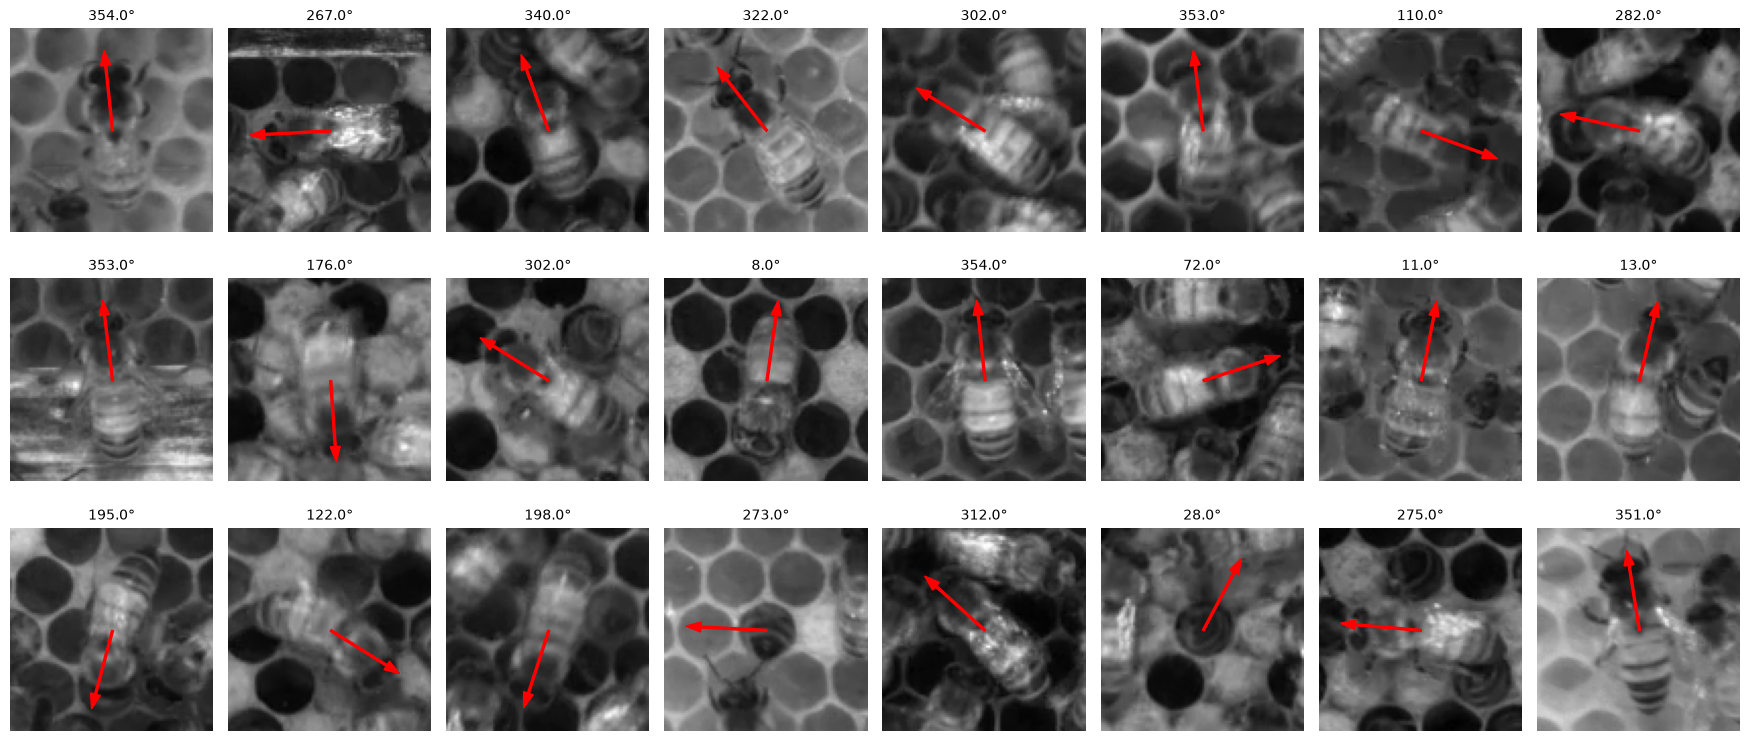

In [9]:
def draw_orientation(ax: plt.Axes, img: Image.Image, theta: float, color: str = "red") -> None:
    """Draw an orientation arrow from the patch center.

    theta is in display convention: theta = atan2(dy, dx), y pointing down,
    as stored in the sample index. For our compass-bearing labels this is
    equivalent to (dx, dy) = (sin(bearing), -cos(bearing)).
    """
    w, h = img.size
    cx, cy = w / 2, h / 2
    r = 0.4 * min(w, h)
    ax.arrow(
        cx, cy, r * math.cos(theta), r * math.sin(theta),
        color=color, width=1.0, head_width=5.0, length_includes_head=True,
    )


def compass_degrees(theta: float) -> float:
    """Display-convention radians back to the raw label bearing (0°=up, clockwise)."""
    return math.degrees(theta + math.pi / 2) % 360


def show_labeled_patches(samples: list[Sample], cfg: Config, n: int = 8, per_row: int = 8) -> None:
    picks = random.sample(samples, min(n, len(samples)))
    n_rows = math.ceil(len(picks) / per_row)
    fig, axes = plt.subplots(
        n_rows, per_row, figsize=(2.2 * per_row, 2.6 * n_rows), squeeze=False
    )
    for ax in axes.flat:
        ax.axis("off")
    for ax, s in zip(axes.flat, picks):
        img = Image.open(s.path).convert("RGB")
        ax.imshow(img)
        draw_orientation(ax, img, s.theta, color="red")
        ax.set_title(f"{compass_degrees(s.theta):.1f}°", fontsize=10)
    plt.tight_layout()
    plt.show()


random.seed(cfg.seed)
# n=24 gives a rough feel for the head/tail flip rate; bump for a better estimate.
show_labeled_patches(train_samples, cfg, n=24)

## Models

All three architectures come from `timm` with the classification head replaced
by a 2-unit linear layer predicting `[sin(k·theta), cos(k·theta)]`.

In [10]:
def create_model(name: str, cfg: Config) -> nn.Module:
    return timm.create_model(name, pretrained=cfg.pretrained, num_classes=2)

## Loss & metrics

- **Loss** — `cosine_loss`: `1 - cosine_similarity(output, target)`, i.e. the
  prediction is L2-normalized and compared to the unit target. Equivalent to
  `1 - cos(k·Δθ)`, a pure function of the angular error (`F.cosine_similarity`
  handles the near-zero-norm case with its built-in eps). One caveat: the
  gradient `sin(Δ)` vanishes at exactly 180°, so predictions pointing
  backwards get weak gradients early in training — the price of bounded,
  outlier-robust loss for flipped labels.
- `mae_deg` / `median_ae_deg` / `rmse_deg`: primary error, wrap-around-safe.
  In axial mode these are computed mod 180°.
- `axial_mae_deg`: error mod 180°, always reported. Comparing it with
  `mae_deg` separates "wrong axis" from "right axis but flipped 180°".
- `acc15/30/45_deg`: percentage of predictions within 15°/30°/45°.
- `loss`: the cosine loss itself — interpretable via `1 - cos(Δθ)`
  (e.g. 0.1 ≈ 26° error), but lead with the degree-space metrics.

In [11]:
LossFn = Callable[[torch.Tensor, torch.Tensor], torch.Tensor]


def cosine_loss(outputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """1 - cos(k * delta_theta): the raw (N, 2) output is L2-normalized onto the
    unit circle and compared to the unit target, so the loss depends only on
    the angular error — ~ (k*delta)^2 / 2 near zero, flattening towards the
    period boundary (flipped-label outliers contribute a bounded loss of 2).
    """
    return (1.0 - F.cosine_similarity(outputs, targets, dim=1)).mean()


def angles_from_sincos(output: torch.Tensor, cfg: Config) -> torch.Tensor:
    """Decode theta from a (N, 2) [sin, cos] prediction."""
    return torch.atan2(output[:, 0], output[:, 1]) / cfg.angle_multiplier


def signed_angular_error(theta_true: torch.Tensor, theta_pred: torch.Tensor) -> torch.Tensor:
    """Wrap-around-safe directional error in (-pi, pi]."""
    diff = theta_true - theta_pred
    return torch.atan2(torch.sin(diff), torch.cos(diff))


def signed_axial_error(theta_true: torch.Tensor, theta_pred: torch.Tensor) -> torch.Tensor:
    """Error mod 180 degrees, in (-pi/2, pi/2] — ignores head/tail flips."""
    diff = theta_true - theta_pred
    return torch.atan2(torch.sin(2.0 * diff), torch.cos(2.0 * diff)) / 2.0


def angular_metrics(theta_true: np.ndarray, theta_pred: np.ndarray, cfg: Config) -> dict[str, float]:
    t_true = torch.from_numpy(theta_true)
    t_pred = torch.from_numpy(theta_pred)
    axial_err = signed_axial_error(t_true, t_pred)
    # In axial mode the directional error is meaningless — the axial error is primary.
    primary_err = axial_err if cfg.axial_labels else signed_angular_error(t_true, t_pred)
    abs_deg = torch.rad2deg(primary_err.abs())
    return {
        "mae_deg": abs_deg.mean().item(),
        "median_ae_deg": abs_deg.median().item(),
        "rmse_deg": torch.sqrt(torch.rad2deg(primary_err).pow(2).mean()).item(),
        "axial_mae_deg": torch.rad2deg(axial_err.abs()).mean().item(),
        "acc15_deg": (abs_deg <= 15).float().mean().item() * 100,
        "acc30_deg": (abs_deg <= 30).float().mean().item() * 100,
        "acc45_deg": (abs_deg <= 45).float().mean().item() * 100,
    }


def metrics_for_predictions(
    theta_true: np.ndarray, theta_pred: np.ndarray, cfg: Config
) -> dict[str, float]:
    """Full metric set (incl. cosine loss) for arbitrary angle predictions."""
    k = cfg.angle_multiplier
    # For unit vectors the cosine loss reduces to 1 - cos(k * delta_theta).
    loss = float(np.mean(1.0 - np.cos(k * (theta_true - theta_pred))))
    return {"loss": loss, **angular_metrics(theta_true, theta_pred, cfg)}

## Baselines

Context for the comparison table: a uniform-random predictor scores 90° MAE
(45° axial), and predicting the circular mean of the train labels is the
honest floor any model must beat.

In [12]:
def circular_mean(theta: np.ndarray, cfg: Config) -> float:
    k = cfg.angle_multiplier
    return float(np.arctan2(np.sin(k * theta).mean(), np.cos(k * theta).mean()) / k)


def baseline_metrics(
    train_samples: list[Sample], test_samples: list[Sample], cfg: Config
) -> dict[str, dict[str, float]]:
    rng = np.random.default_rng(cfg.seed)
    train_thetas = np.array([s.theta for s in train_samples])
    test_thetas = np.array([s.theta for s in test_samples])

    mean_pred = np.full_like(test_thetas, circular_mean(train_thetas, cfg))
    random_pred = rng.uniform(-math.pi, math.pi, size=len(test_thetas))

    return {
        "baseline: circular mean": metrics_for_predictions(test_thetas, mean_pred, cfg),
        "baseline: uniform random": metrics_for_predictions(test_thetas, random_pred, cfg),
    }

## Training & evaluation loops

Per-epoch history and final test metrics are written to
`checkpoints/{name}_history.csv` / `{name}_test_metrics.json` as they are
produced, so nothing is lost if the kernel dies mid-run on a shared node.

In [13]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: LossFn,
    scaler: torch.amp.GradScaler,
    cfg: Config,
    desc: str = "train",
) -> float:
    model.train()
    total_loss, n_samples = 0.0, 0
    batches = tqdm(loader, desc=desc, unit="batch", leave=False)
    for images, targets in batches:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=cfg.use_amp):
            outputs = model(images)
            loss = criterion(outputs, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * images.size(0)
        n_samples += images.size(0)
        batches.set_postfix(loss=f"{total_loss / n_samples:.4f}")
    return total_loss / n_samples


@torch.no_grad()
def evaluate(
    model: nn.Module, loader: DataLoader, criterion: LossFn, cfg: Config, desc: str = "eval"
) -> tuple[dict[str, float], np.ndarray, np.ndarray]:
    """Returns (metrics, theta_true, theta_pred) over the whole loader."""
    model.eval()
    total_loss, n_samples = 0.0, 0
    trues: list[torch.Tensor] = []
    preds: list[torch.Tensor] = []
    for images, targets in tqdm(loader, desc=desc, unit="batch", leave=False):
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        with torch.autocast(device_type=device.type, enabled=cfg.use_amp):
            outputs = model(images)
            loss = criterion(outputs, targets)
        total_loss += loss.item() * images.size(0)
        n_samples += images.size(0)
        trues.append(angles_from_sincos(targets.float(), cfg).cpu())
        preds.append(angles_from_sincos(outputs.float(), cfg).cpu())
    theta_true = torch.cat(trues).numpy()
    theta_pred = torch.cat(preds).numpy()
    metrics = {"loss": total_loss / n_samples, **angular_metrics(theta_true, theta_pred, cfg)}
    return metrics, theta_true, theta_pred


@dataclass
class RunResult:
    model_name: str
    history: pd.DataFrame
    test_metrics: dict[str, float]
    theta_true: np.ndarray
    theta_pred: np.ndarray
    checkpoint_path: Path


def train_and_evaluate(
    name: str,
    cfg: Config,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
) -> RunResult:
    print(f"\n=== {name} ===")
    seed_everything(cfg.seed)

    # 1. Create the model and send to the primary device
    model = create_model(name, cfg).to(device)
    
    # 2. WRAP WITH DATAPARALLEL HERE
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs with DataParallel!")
        model = nn.DataParallel(model)
    
    criterion = cosine_loss
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)
    scaler = torch.amp.GradScaler(device.type, enabled=cfg.use_amp and device.type == "cuda")

    cfg.checkpoint_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = cfg.checkpoint_dir / f"{name}_best.pt"
    history_path = cfg.checkpoint_dir / f"{name}_history.csv"

    history: list[dict[str, float]] = []
    best_val_mae = float("inf")

    epochs = tqdm(range(1, cfg.epochs + 1), desc=name, unit="epoch")
    for epoch in epochs:
        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion, scaler, cfg,
            desc=f"epoch {epoch}/{cfg.epochs} · train",
        )
        val_metrics, _, _ = evaluate(
            model, val_loader, criterion, cfg, desc=f"epoch {epoch}/{cfg.epochs} · val"
        )
        scheduler.step()

        history.append({"epoch": epoch, "train_loss": train_loss, **{f"val_{k}": v for k, v in val_metrics.items()}})
        pd.DataFrame(history).to_csv(history_path, index=False)

        marker = ""
        if val_metrics["mae_deg"] < best_val_mae:
            best_val_mae = val_metrics["mae_deg"]
            torch.save(model.state_dict(), checkpoint_path)
            marker = "  *"
        epochs.set_postfix(
            train_loss=f"{train_loss:.4f}",
            val_loss=f"{val_metrics['loss']:.4f}",
            val_mae=f"{val_metrics['mae_deg']:.2f}°",
            best=f"{best_val_mae:.2f}°",
        )
        epochs.write(
            f"epoch {epoch:3d} | train loss {train_loss:.4f} | "
            f"val loss {val_metrics['loss']:.4f} | val MAE {val_metrics['mae_deg']:6.2f}°{marker}"
        )

    model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
    test_metrics, theta_true, theta_pred = evaluate(model, test_loader, criterion, cfg, desc=f"{name} · test")
    (cfg.checkpoint_dir / f"{name}_test_metrics.json").write_text(json.dumps(test_metrics, indent=2))
    print(f"test: loss {test_metrics['loss']:.4f} | MAE {test_metrics['mae_deg']:.2f}° | median {test_metrics['median_ae_deg']:.2f}°")

    return RunResult(
        model_name=name,
        history=pd.DataFrame(history),
        test_metrics=test_metrics,
        theta_true=theta_true,
        theta_pred=theta_pred,
        checkpoint_path=checkpoint_path,
    )

## Tiny-subset overfit check

Trains ResNet-18 on 128 samples and evaluates on those **same** samples — a
pure memorization test of the pipeline, run once before spending hours on
full training. **Pass:** loss falls well below 0.05 and MAE below ~10° within
the 60 epochs. **Fail:** loss stalls near 1.0 / MAE near 90°, meaning labels,
targets, decode, or loss are inconsistent somewhere — do not start full
training. (Says nothing about generalization; checkpoints go to a separate
`checkpoints_overfit/` dir, which can be deleted afterwards.)

In [14]:
overfit_cfg = replace(
    cfg,
    epochs=60,
    batch_size=32,
    num_workers=0,
    rotation_augment=False,
    checkpoint_dir=cfg.checkpoint_dir.parent / "checkpoints_overfit",
)
tiny = random.Random(cfg.seed).sample(train_samples, 128)
tiny_train, tiny_val, tiny_test = make_loaders(tiny, tiny, tiny, overfit_cfg)
overfit_result = train_and_evaluate("resnet18", overfit_cfg, tiny_train, tiny_val, tiny_test)


=== resnet18 ===


Using 4 GPUs with DataParallel!


resnet18:   0%|          | 0/60 [00:00<?, ?epoch/s]

epoch 1/60 · train:   0%|          | 0/4 [00:00<?, ?batch/s]

epoch 1/60 · val:   0%|          | 0/4 [00:00<?, ?batch/s]

...

epoch 60/60 · train:   0%|          | 0/4 [00:00<?, ?batch/s]

epoch 60/60 · val:   0%|          | 0/4 [00:00<?, ?batch/s]

epoch  60 | train loss 0.0126 | val loss 0.0048 | val MAE   4.24°


resnet18 · test:   0%|          | 0/4 [00:00<?, ?batch/s]

test: loss 0.0048 | MAE 4.16° | median 3.19°


## Run all experiments

**Do not run until the sanity-check gate above passes** — training three
models on labels with the wrong units, convention, or head/tail assumption
costs hours of HPC time and produces meaningless numbers.

In [ ]:
results: dict[str, RunResult] = {}
for name in cfg.model_names:
    results[name] = train_and_evaluate(name, cfg, train_loader, val_loader, test_loader)


=== resnet18 ===
Using 4 GPUs with DataParallel!


resnet18:   0%|          | 0/15 [00:00<?, ?epoch/s]

epoch 1/15 · train:   0%|          | 0/11089 [00:24<?, ?batch/s]

epoch 1/15 · val:   0%|          | 0/2325 [00:15<?, ?batch/s]

epoch   1 | train loss 0.0986 | val loss 0.0982 | val MAE  13.07°  *


...

epoch   4 | train loss 0.0622 | val loss 0.0991 | val MAE  12.91°


epoch 5/15 · train:   0%|          | 0/11089 [00:00<?, ?batch/s]

epoch 5/15 · val:   0%|          | 0/2325 [00:00<?, ?batch/s]

epoch   5 | train loss 0.0576 | val loss 0.0836 | val MAE  11.19°  *


epoch 6/15 · train:   0%|          | 0/11089 [00:00<?, ?batch/s]

## Model comparison

Degree-space metrics are the ones to read; `loss` is the cosine loss
`1 - cos(k·Δθ)` on the test set. The baseline rows give the context: models
must clearly beat the circular-mean floor, and an MAE near the random
baseline (90°, or 45° axial) suggests head/tail-ambiguous labels.

In [ ]:
comparison_rows = {name: res.test_metrics for name, res in results.items()}
comparison_rows.update(baseline_metrics(train_samples, test_samples, cfg))
metric_order = ["mae_deg", "median_ae_deg", "rmse_deg", "axial_mae_deg",
                "acc15_deg", "acc30_deg", "acc45_deg", "loss"]
comparison = pd.DataFrame(comparison_rows).T.rename_axis("model")[metric_order]
comparison.round(2)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, res in results.items():
    axes[0].plot(res.history["epoch"], res.history["train_loss"], label=f"{name} (train)")
    axes[0].plot(res.history["epoch"], res.history["val_loss"], "--", label=f"{name} (val)")
    axes[1].plot(res.history["epoch"], res.history["val_mae_deg"], label=name)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("1 − cos(Δθ)"); axes[0].set_title("cosine loss"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("val MAE [°]"); axes[1].set_title("Validation angular error"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Error diagnostics

Histogram: secondary modes at ±180° indicate head/tail flips. Scatter of
error vs. true angle: reveals systematic bias near particular orientations
that the histogram hides.

In [ ]:
def primary_error_deg(res: RunResult, cfg: Config) -> np.ndarray:
    t_true = torch.from_numpy(res.theta_true)
    t_pred = torch.from_numpy(res.theta_pred)
    err = signed_axial_error(t_true, t_pred) if cfg.axial_labels else signed_angular_error(t_true, t_pred)
    return np.degrees(err.numpy())


err_range = 90.0 if cfg.axial_labels else 180.0
fig, axes = plt.subplots(2, len(results), figsize=(4.5 * len(results), 7), squeeze=False)
for col, (name, res) in enumerate(results.items()):
    err_deg = primary_error_deg(res, cfg)
    axes[0][col].hist(err_deg, bins=72, range=(-err_range, err_range))
    axes[0][col].set_title(f"{name}\nMAE {res.test_metrics['mae_deg']:.1f}°")
    axes[0][col].set_xlabel("signed error [°]")
    axes[1][col].scatter(np.degrees(res.theta_true), err_deg, s=2, alpha=0.3)
    axes[1][col].axhline(0.0, color="black", lw=0.5)
    axes[1][col].set_xlabel("true angle [°]")
    axes[1][col].set_ylabel("signed error [°]")
plt.tight_layout()
plt.show()

## Qualitative results

Red arrow: ground truth. Blue arrow: prediction of the best model (lowest test MAE).

In [ ]:
best_name = comparison.loc[list(results)]["mae_deg"].idxmin()
best_res = results[best_name]
print(f"Best model: {best_name}")

best_model = create_model(best_name, cfg).to(device)
best_model.load_state_dict(
    torch.load(best_res.checkpoint_path, map_location=device, weights_only=True)
)
best_model.eval()


@torch.no_grad()
def show_predictions(samples: list[Sample], model: nn.Module, cfg: Config, n: int = 8) -> None:
    picks = random.sample(samples, min(n, len(samples)))
    ds = BeeOrientationDataset(picks, cfg)
    images = torch.stack([ds[i][0] for i in range(len(picks))]).to(device)
    theta_pred = angles_from_sincos(model(images).float(), cfg).cpu().numpy()

    fig, axes = plt.subplots(1, len(picks), figsize=(2.2 * len(picks), 2.6))
    for ax, s, tp in zip(np.atleast_1d(axes), picks, theta_pred):
        img = Image.open(s.path).convert("RGB")
        ax.imshow(img)
        draw_orientation(ax, img, s.theta, color="red")
        draw_orientation(ax, img, float(tp), color="deepskyblue")
        err = math.degrees(math.atan2(math.sin(s.theta - tp), math.cos(s.theta - tp)))
        ax.set_title(f"err {err:+.1f}°", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


show_predictions(test_samples, best_model, cfg)